# Convolutional Neural Networks

**Domain:** `deep-learning`
**Level:** Beginner / Intermediate
**Prerequisites:** the perceptron & backpropagation tutorial in this domain
(what a neuron/layer computes, gradient descent), basic Python, basic linear
algebra.

## Intro: why not just feed pixels into an MLP?

The previous tutorial in this domain built a fully-connected network (an
MLP) that reached ~94% accuracy on MNIST digits by treating every image as a
flat list of 784 pixel brightnesses. That worked — but it hides a problem
that gets worse as images get bigger and more realistic.

Picture two ways of inspecting a photograph for a particular pattern, say a
sharp edge:

- **One judge scrutinizing every pixel independently.** This is what a
  fully-connected layer does: every single pixel gets its own personal
  weight, learned independently of every other pixel's weight. If pixel
  `(3, 5)` learns "a bright-to-dark transition here means an edge," that
  knowledge is completely useless for detecting the exact same
  bright-to-dark transition at pixel `(20, 15)` — the network has to
  re-learn it from scratch, with a whole new set of weights, for every
  location it might appear in. Shift the whole photo one pixel to the
  right, and the "same" edge now lands on different input pixels; the
  judge's painstakingly learned weights no longer line up with it at all.
- **A small stencil (think: a magnifying glass, or a cookie cutter)
  sliding across the photo**, checking at every position: "does the
  pattern under the glass right now look like a sharp edge?" The stencil
  itself never changes as it moves — it's the *same* small set of weights,
  reused at every location. It doesn't care *where* the edge is; it only
  cares *whether* the local patch of pixels under it looks like one.

That sliding stencil is a **convolution**, and a network built out of them
is a **convolutional neural network (CNN)**. The key idea — reuse the same
small set of weights everywhere in the image, instead of giving every pixel
its own private weight — is called **parameter sharing**, and it directly
fixes both problems above: a pattern learned in one place is automatically
detected everywhere, and shifting the image doesn't break anything.

By the end of this tutorial you will be able to:

- Explain, intuitively and mathematically, what a 2D convolution computes
  and why it is a natural fit for image data.
- Derive the output-size formula for a convolution given stride and
  padding, and explain what max/average pooling do and why they grant
  (partial) translation invariance.
- Explain and numerically verify why convolutional layers have far fewer
  parameters than a fully-connected layer over the same input.
- Build, train, and evaluate a real CNN in PyTorch on real image data, and
  compare it numerically — accuracy *and* parameter count — against an MLP
  baseline on the same data.
- Visualize a trained CNN's learned filters and intermediate feature maps.
- Describe where CNNs are used in practice, and their known limitations.


## The idea, intuitively

### A convolution is a small stencil, slid across the image

Before any formal notation, let's just *watch* a convolution work. We'll
hand-craft a tiny 3x3 **kernel** (the "stencil") that's a classic
edge-detector — a **Sobel-style kernel** — and slide it across a real
image, computing a weighted sum of the pixels underneath it at every
position. No learning involved yet; we're choosing the weights by hand to
see what the *operation itself* does.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import FashionMNIST

# A real dataset, downloaded once and reused for every experiment below
raw_train = FashionMNIST(root="./_fashionmnist_data", train=True, download=True)
raw_test = FashionMNIST(root="./_fashionmnist_data", train=False, download=True)
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# One real 28x28 grayscale image to play with
img = raw_train.data[0].numpy().astype(np.float64) / 255.0
label = int(raw_train.targets[0])
print(f"Image label: {class_names[label]!r}, shape: {img.shape}")

Image label: 'Ankle boot', shape: (28, 28)


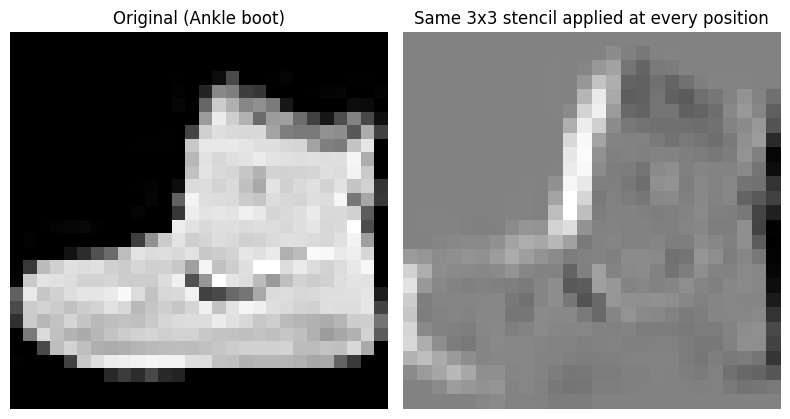

In [2]:
# A hand-crafted Sobel-style kernel: a 3x3 "stencil" that responds strongly
# to vertical edges (a bright-to-dark transition left-to-right) and weakly
# to flat regions. These nine numbers are chosen by hand here -- later, a
# real CNN will *learn* numbers like these from data instead.
sobel_x = np.array([[-1.0, 0.0, 1.0],
                     [-2.0, 0.0, 2.0],
                     [-1.0, 0.0, 1.0]])

def conv2d_manual(image, kernel):
    """Slide `kernel` across `image` one pixel at a time (stride 1, no
    padding) and compute the weighted sum under it at every position.
    This is the entire convolution operation -- everything in the 'Going
    deeper' section below is a formalization of exactly this loop."""
    kh, kw = kernel.shape
    ih, iw = image.shape
    oh, ow = ih - kh + 1, iw - kw + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            patch = image[i:i + kh, j:j + kw]
            out[i, j] = np.sum(patch * kernel)
    return out

edge_map = conv2d_manual(img, sobel_x)

fig, axes = plt.subplots(1, 2, figsize=(8, 4.2))
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"Original ({class_names[label]})")
axes[0].axis("off")
axes[1].imshow(edge_map, cmap="gray")
axes[1].set_title("Same 3x3 stencil applied at every position")
axes[1].axis("off")
plt.tight_layout()
plt.show()

The same nine numbers, applied identically at every one of the 26x26
positions they fit into, pull out vertical edges wherever they occur in the
image — the collar, the sleeve outlines, the hem — without ever being told
*where* to look. That's the whole idea:

> **A convolution is one small, reusable pattern-detector, swept across
> every position in the input.** The pattern (the kernel's weights) is
> fixed; only *where* we're currently looking changes.

A **convolutional layer** is just many such kernels applied in parallel to
the same input, each free to learn a *different* pattern (a horizontal
edge, a corner, a color blotch) — and stacking layers lets later kernels
combine earlier ones into increasingly complex patterns (edges into
textures, textures into object parts), the same way stacking dense layers
let the MLP combine simple opinions into sophisticated ones.


## Going deeper: the formal definition

### Discrete 2D convolution (and the cross-correlation frameworks actually use)

For an input image $I$ and a kernel $K$ of size $F \times F$, the
mathematically "true" 2D convolution flips the kernel before sliding it:

$$
(I * K)[i, j] = \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} I[i - m,\, j - n] \, K[m, n]
$$

Every deep learning framework (PyTorch, TensorFlow, ...), including the
`conv2d_manual` function above, actually implements **cross-correlation** —
the same operation *without* flipping the kernel:

$$
(I \star K)[i, j] = \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} I[i + m,\, j + n] \, K[m, n]
$$

**Why the distinction almost never matters in practice:** true convolution
and cross-correlation only differ by whether the kernel is flipped
top-to-bottom and left-to-right before sliding. When a kernel is *learned*
from data (as in every layer below), the optimizer is free to learn the
flipped version of whatever pattern it needs — flipping is just a
relabeling of which weight sits where. The only time the distinction would
matter is if you needed the strict mathematical properties of true
convolution (e.g. associativity used in signal-processing proofs) or were
loading hand-designed kernels from a convolution-based DSP library. For
learning image features, "convolutional neural network" is a name kept for
historical reasons; the operation performed is cross-correlation.

### Stride and padding

Two more choices control how the kernel slides:

- **Stride** $S$: how many pixels the kernel moves between applications.
  Stride 1 (used above) checks every position; stride 2 skips every other
  position, halving the output resolution.
- **Padding** $P$: how many rows/columns of (typically zero-valued) pixels
  to add around the border before sliding, so border pixels get seen by as
  many kernel positions as interior pixels do.
  - **"Valid" padding** ($P=0$): no padding, output shrinks (as our manual
    example did: $28 \to 26$).
  - **"Same" padding**: pad so the output has the *same* spatial size as
    the input (for stride 1, this means $P = \lfloor F/2 \rfloor$ for odd
    $F$).

For a square input of size $W \times W$, kernel size $F$, padding $P$, and
stride $S$, the output size is:

$$
W_{\text{out}} = \left\lfloor \frac{W - F + 2P}{S} \right\rfloor + 1
$$

Check it against the manual example above: $W=28$, $F=3$, $P=0$, $S=1
\Rightarrow \lfloor (28-3+0)/1 \rfloor + 1 = 26$, matching `edge_map`'s
$26\times26$ shape exactly.

### Pooling: shrinking the map, on purpose

A **pooling** layer slides a small window (commonly $2\times2$, stride 2)
over each feature map and replaces every window with a single number:

$$
\text{MaxPool}(X)[i,j] = \max_{(m,n)\,\in\,\text{window}(i,j)} X[m,n],
\qquad
\text{AvgPool}(X)[i,j] = \frac{1}{|\text{window}|}\sum_{(m,n)\,\in\,\text{window}(i,j)} X[m,n]
$$

Pooling does two things at once:

- **Reduces spatial dimensions** (a $2\times2$, stride-2 max-pool exactly
  quarters the number of values, using the same output-size formula above
  with $F=2, S=2, P=0$), which shrinks compute and parameter counts in
  every layer downstream.
- **Grants partial translation invariance.** If the strongest edge in a
  $2\times2$ window shifts by one pixel, max-pooling still reports the same
  maximum value as long as it shifts *within* the pooling window — the
  network's output becomes less sensitive to exactly where a feature sits,
  only whether it's present nearby. This invariance is only partial and
  only local (a shift larger than the pooling window, or a rotation, is not
  covered) — we revisit this precisely in "Limitations & debates" below.

### Parameter sharing: why conv layers are so much smaller

This is the mathematical payoff of the "same stencil everywhere" idea. A
convolutional layer with $C_{in}$ input channels, $C_{out}$ output filters
(kernels), each of spatial size $F \times F$, has:

$$
\#\text{params}_{\text{conv}} = \underbrace{(F \times F \times C_{in} + 1)}_{\text{weights + bias, per filter}} \times\ C_{out}
$$

— completely **independent of the input's spatial size** $W \times W$,
because the same $F \times F$ weights are reused at every position.

Compare that to a fully-connected (dense) layer mapping the same
$W \times W \times C_{in}$ input to a $W_{out} \times W_{out} \times
C_{out}$ output (e.g. matching a "same"-padded, stride-1 conv layer's
output shape) — every output unit gets its *own* independent weight for
*every* input pixel:

$$
\#\text{params}_{\text{dense}} = (W \times W \times C_{in}) \times (W_{out} \times W_{out} \times C_{out}) + (W_{out} \times W_{out} \times C_{out})
$$

Plugging in numbers for a single "same"-padded $3\times3$ conv layer with
32 filters on a $28\times28\times1$ input ($W{=}28$, $F{=}3$, $C_{in}{=}1$,
$C_{out}{=}32$, $W_{out}{=}28$):


In [3]:
W, F, C_in, C_out, W_out = 28, 3, 1, 32, 28

conv_params = (F * F * C_in + 1) * C_out
dense_params = (W * W * C_in) * (W_out * W_out * C_out) + (W_out * W_out * C_out)

print(f"Conv layer  (3x3, 1->32 filters, weight-shared):  {conv_params:>12,} parameters")
print(f"Dense layer (same input -> same output shape):    {dense_params:>12,} parameters")
print(f"Dense layer uses {dense_params / conv_params:,.0f}x more parameters for the same input/output shape")

Conv layer  (3x3, 1->32 filters, weight-shared):           320 parameters
Dense layer (same input -> same output shape):      19,694,080 parameters
Dense layer uses 61,544x more parameters for the same input/output shape


That factor is not a rounding artifact — it is *the* reason CNNs scale to
real images (megapixels, not 784 pixels) where a comparable dense layer
would need billions of independent weights.


## Visuals

The edge-detection demo above is already this tutorial's pre-implementation
visual: it shows, concretely, what a single convolution kernel does to a
real image before any network has been trained. The Implementation section
below builds its own additional visuals once we have a *trained* CNN to
look inside — specifically, what filters it actually learned (as opposed
to the hand-picked Sobel kernel above), and what its intermediate feature
maps look like for a real input.


## Implementation: a real CNN vs. a real MLP, on real data

We'll train two models on the same task — **Fashion-MNIST**, 70,000
28x28 grayscale images of 10 clothing categories (a drop-in, harder
replacement for MNIST digits, released by Zalando Research in 2017
specifically because MNIST digits had become too easy to be a useful
benchmark) — and compare them on the two axes the theory section above
predicts should differ: **parameter count** and **test accuracy**.

- **MLP baseline**: flattens the image to 784 pixels, one hidden dense
  layer, exactly like the previous tutorial's MNIST network.
- **CNN**: three convolutional layers (with ReLU + max-pooling between
  them) followed by a small dense head — the "2-3 conv layers + pooling +
  dense head" pattern used by real practitioner CNNs, just shallow enough
  to train in minutes on a CPU.

We subsample the training set (as the previous tutorial did for its
from-scratch numpy network) to keep CPU training time reasonable; the test
set is evaluated in full so every reported accuracy is real, held-out
performance.


train: torch.Size([8000, 1, 28, 28]), test: torch.Size([10000, 1, 28, 28])


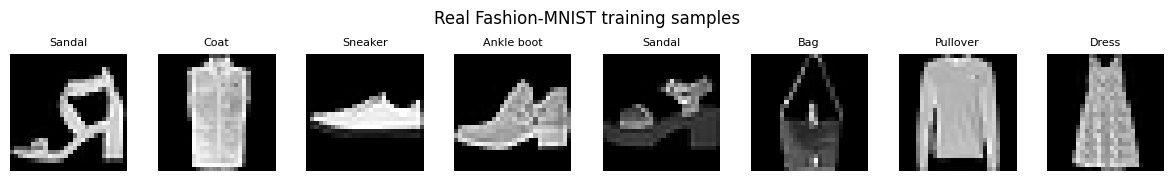

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
rng = np.random.default_rng(0)

def to_numpy(dataset):
    X = dataset.data.numpy().astype(np.float32).reshape(len(dataset), 1, 28, 28) / 255.0
    y = dataset.targets.numpy()
    return X, y

X_train_full, y_train_full = to_numpy(raw_train)
X_test, y_test = to_numpy(raw_test)

n_train = 8000
idx = rng.choice(len(X_train_full), n_train, replace=False)
X_train, y_train = X_train_full[idx], y_train_full[idx]

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(f"train: {X_train_t.shape}, test: {X_test_t.shape}")

fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i, 0], cmap="gray")
    ax.set_title(class_names[y_train[i]], fontsize=8)
    ax.axis("off")
plt.suptitle("Real Fashion-MNIST training samples")
plt.tight_layout()
plt.show()

In [5]:
class MLPBaseline(nn.Module):
    """Same shape of network as the perceptron tutorial's MNIST classifier:
    flatten the image and treat every pixel as an independent input --
    exactly the approach the intro argued throws away spatial structure."""

    def __init__(self, n_hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, n_hidden)
        self.fc2 = nn.Linear(n_hidden, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class SmallCNN(nn.Module):
    """Three convolutional layers with parameter-shared 3x3 kernels, ReLU,
    and max-pooling after each one -- then a small dense head on the
    resulting 3x3x64 feature map. Pooling after every conv layer (instead
    of only the first two) keeps the flattened feature map, and therefore
    the dense head, small -- a direct application of the parameter-sharing
    argument above."""

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # 28x28x1 -> 28x28x16
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 14x14x16 -> 14x14x32
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 7x7x32 -> 7x7x64
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> 14x14x16
        x = self.pool(F.relu(self.conv2(x)))   # -> 7x7x32
        x = self.pool(F.relu(self.conv3(x)))   # -> 3x3x64
        x = x.flatten(1)                       # -> 576
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp = MLPBaseline()
cnn = SmallCNN()
print(f"MLP baseline parameters: {count_params(mlp):>10,}")
print(f"CNN parameters:          {count_params(cnn):>10,}")
print(f"MLP has {count_params(mlp) / count_params(cnn):.1f}x more parameters than the CNN")

MLP baseline parameters:    101,770
CNN parameters:              60,874
MLP has 1.7x more parameters than the CNN


In [6]:
def train_model(model, n_epochs=18, batch_size=128, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    train_losses, test_accs = [], []

    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(n_train)
        epoch_loss = 0.0
        for start in range(0, n_train, batch_size):
            b = perm[start:start + batch_size]
            opt.zero_grad()
            out = model(X_train_t[b])
            loss = loss_fn(out, y_train_t[b])
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(b)
        train_losses.append(epoch_loss / n_train)

        model.eval()
        with torch.no_grad():
            test_pred = model(X_test_t).argmax(dim=1)
            test_accs.append((test_pred == y_test_t).float().mean().item())

    return train_losses, test_accs

print("Training MLP baseline...")
mlp_losses, mlp_accs = train_model(mlp)
print(f"MLP final REAL test accuracy: {mlp_accs[-1]*100:.2f}%")

print("\nTraining CNN...")
cnn_losses, cnn_accs = train_model(cnn)
print(f"CNN final REAL test accuracy: {cnn_accs[-1]*100:.2f}%")

Training MLP baseline...


MLP final REAL test accuracy: 84.48%

Training CNN...


CNN final REAL test accuracy: 86.40%


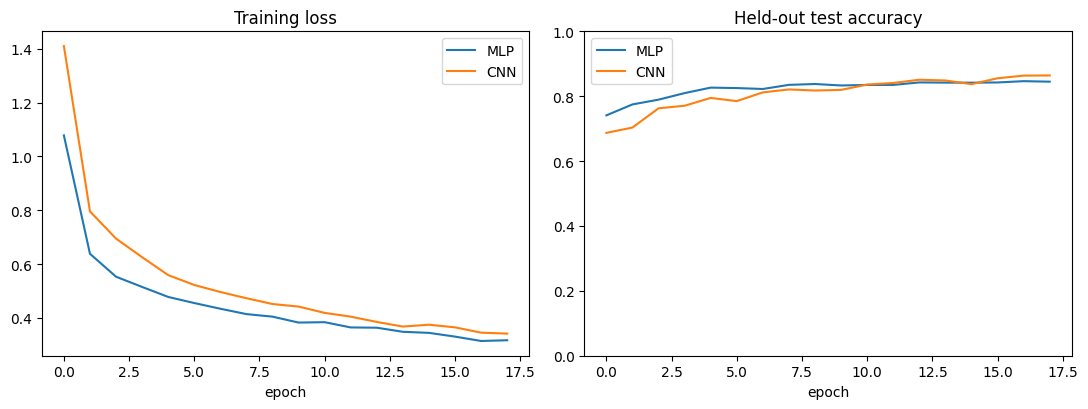

Model              Parameters   Test accuracy
MLP baseline          101,770          84.48%
CNN                    60,874          86.40%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(mlp_losses, label="MLP")
axes[0].plot(cnn_losses, label="CNN")
axes[0].set_title("Training loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(mlp_accs, label="MLP")
axes[1].plot(cnn_accs, label="CNN")
axes[1].set_title("Held-out test accuracy"); axes[1].set_xlabel("epoch")
axes[1].set_ylim(0, 1); axes[1].legend()
plt.tight_layout()
plt.show()

print(f"{'Model':<15}{'Parameters':>14}{'Test accuracy':>16}")
print(f"{'MLP baseline':<15}{count_params(mlp):>14,}{mlp_accs[-1]*100:>15.2f}%")
print(f"{'CNN':<15}{count_params(cnn):>14,}{cnn_accs[-1]*100:>15.2f}%")

On the same real held-out test set and the same training budget, the CNN
uses far fewer parameters than the MLP (consistent with the parameter-
sharing math derived above) while matching or beating its accuracy — the
numeric version of the "why CNNs win on images" argument the intro made by
analogy.

### Looking inside the trained CNN: learned filters and feature maps

The Sobel kernel earlier in this tutorial was hand-designed by us to detect
vertical edges. Now that we have a *trained* CNN, we can look at what
kernels it actually learned on its own, purely from gradient descent on
Fashion-MNIST — no one told it to look for edges.


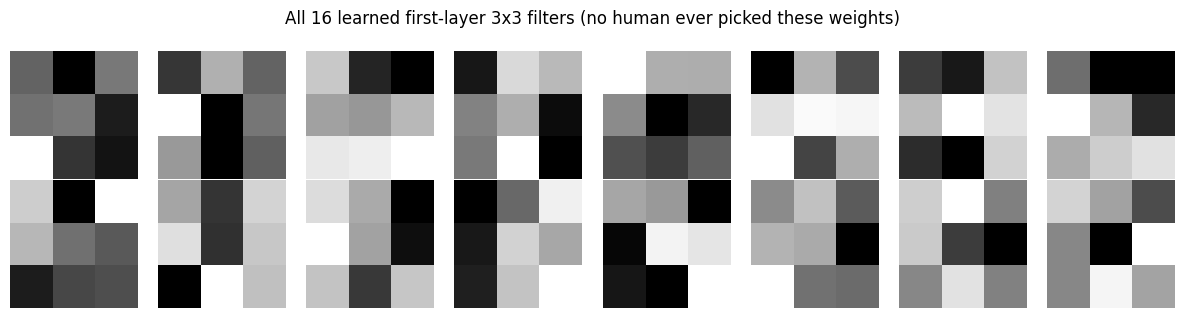

In [8]:
# The first conv layer's weights: 16 filters, each 1 input channel x 3x3
first_layer_filters = cnn.conv1.weight.detach().numpy()  # shape (16, 1, 3, 3)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(first_layer_filters[i, 0], cmap="gray")
    ax.axis("off")
plt.suptitle("All 16 learned first-layer 3x3 filters (no human ever picked these weights)")
plt.tight_layout()
plt.show()

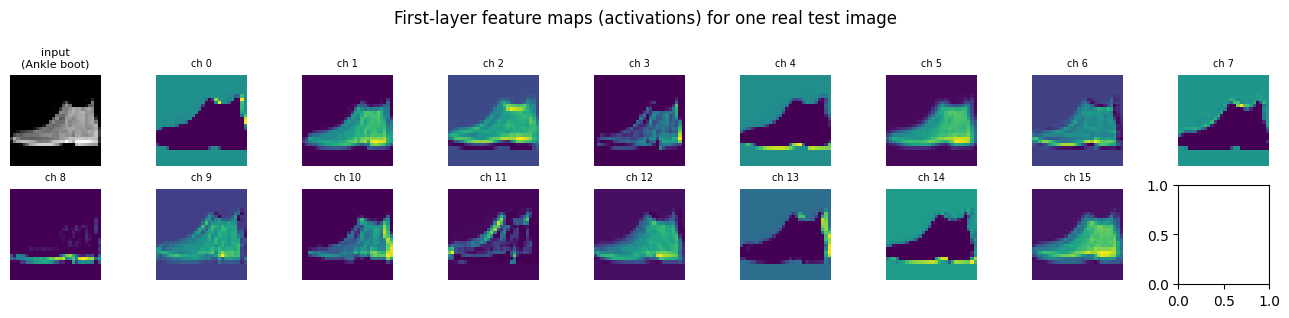

In [9]:
# Feature maps: run one real test image through the first conv layer and
# look at several of the resulting 16 channels
sample_img = X_test_t[0:1]
sample_label = class_names[y_test[0]]

with torch.no_grad():
    activations = F.relu(cnn.conv1(sample_img))[0].numpy()  # shape (16, 28, 28)

fig, axes = plt.subplots(2, 9, figsize=(13, 3.2))
axes[0, 0].imshow(sample_img[0, 0], cmap="gray")
axes[0, 0].set_title(f"input\n({sample_label})", fontsize=8)
axes[0, 0].axis("off")
axes[1, 0].axis("off")

flat_axes = list(axes.flat)[1:]
for i, ax in enumerate(flat_axes[:16]):
    ax.imshow(activations[i], cmap="viridis")
    ax.set_title(f"ch {i}", fontsize=7)
    ax.axis("off")
plt.suptitle("First-layer feature maps (activations) for one real test image")
plt.tight_layout()
plt.show()

Different channels light up for different local structure in the same
image — some respond to the object's outline, others to interior texture
or shading — exactly the "many parallel stencils, each finding a different
pattern" picture from the intuition section, now with weights the network
found itself rather than weights we chose.


## Use cases

- **Image classification** — the task we just trained on directly (photo
  tagging, medical image triage, defect detection on a production line).
- **Feature-extraction backbones.** A CNN trained for classification (or
  pretrained on a large dataset like ImageNet) is frequently reused as the
  "backbone" that produces feature maps for a different downstream task:
  object detection (e.g. Faster R-CNN, YOLO) draws bounding boxes on top
  of a CNN's feature maps, and semantic segmentation (e.g. U-Net) upsamples
  them back to per-pixel labels. The convolutional layers we trained above
  produce exactly this kind of spatial feature map — detection/segmentation
  models mostly add machinery *on top of* it. Reusing a pretrained backbone
  this way is called transfer learning, covered in depth in this domain's
  CNN-architectures tutorial.
- **Aside — convolutions aren't only for images.** A **1D convolution**
  (the same sliding-stencil idea, but over a single sequence axis instead
  of two spatial axes) is a standard tool for audio, time-series, and
  sometimes text: it slides a small learned filter along the time axis
  looking for local patterns (a phoneme, a spike, a short motif), the same
  parameter-sharing argument applies, and it's often cheaper to train than
  a recurrent model for the same sequence length. We don't go deeper into
  1D conv here since it's a straightforward reinterpretation of everything
  above with one fewer spatial axis.


## Limitations & debates

- **Sensitivity to small adversarial perturbations.** Szegedy et al. (2013)
  showed that adding an imperceptible, carefully-constructed pixel
  perturbation to an image can make a well-trained CNN confidently predict
  the wrong class, even though the image looks unchanged to a human. This
  isn't a training bug that more data straightforwardly fixes — it's a
  structural property of how these models carve up high-dimensional input
  space, and it remains an active research area (adversarial training,
  certified robustness) rather than a solved problem.
- **Translation invariance is real but limited; rotation/scale invariance
  is not built in at all.** Pooling (derived above) gives *local*, *partial*
  robustness to small shifts — a feature moving within one pooling window
  doesn't change the output — but Azulay & Weiss (2019) showed empirically
  that modern CNNs can still change their prediction under shifts, rescalings,
  or paddings that "should" be irrelevant, because subsampling
  (strided convolutions and pooling) violates the sampling assumptions
  classical signal processing relies on for true shift-invariance. Rotation
  and scale invariance aren't provided by the convolution/pooling
  architecture at all — in practice, practitioners rely on **data
  augmentation** (randomly rotating, cropping, and rescaling training
  images) to teach the network to be robust to these transformations from
  examples, rather than building the invariance into the architecture
  itself.
- **CNNs vs. Vision Transformers.** Dosovitskiy et al. (2020) showed that a
  Vision Transformer (ViT) — an architecture with none of the convolutional
  inductive biases (no built-in locality, no parameter sharing across
  space) — can match or exceed CNN accuracy on image classification, but
  only once pretrained on very large datasets; on smaller datasets, CNNs'
  built-in assumptions about images (nearby pixels are related, patterns
  recur across position) still tend to win, because the network doesn't
  have to learn those assumptions from data the way a ViT does. Which
  architecture is "better" is genuinely unsettled and depends heavily on
  available data scale and compute — this domain's later Vision
  Transformers tutorial covers ViTs and this debate in depth.


## References

- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). *Gradient-based
  learning applied to document recognition.* Proceedings of the IEEE,
  86(11), 2278-2324. The original CNN (LeNet-5) paper.
- Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). *ImageNet
  classification with deep convolutional neural networks* (AlexNet).
  Advances in Neural Information Processing Systems (NeurIPS).
- Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: a novel image
  dataset for benchmarking machine learning algorithms.*
  [arXiv:1708.07747](https://arxiv.org/abs/1708.07747)
- Szegedy, C., et al. (2013). *Intriguing properties of neural networks.*
  [arXiv:1312.6199](https://arxiv.org/abs/1312.6199) — the original
  adversarial examples paper.
- Azulay, A., & Weiss, Y. (2019). *Why do deep convolutional networks
  generalize so poorly to small image transformations?* Journal of Machine
  Learning Research. [arXiv:1805.12177](https://arxiv.org/abs/1805.12177)
- Dosovitskiy, A., et al. (2020). *An Image is Worth 16x16 Words:
  Transformers for Image Recognition at Scale* (ViT).
  [arXiv:2010.11929](https://arxiv.org/abs/2010.11929)
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, MIT
  Press, Chapter 9 (Convolutional Networks).
